In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Assuming your file is named 'SuperMarket Analysis.csv'
df = pd.read_csv('SuperMarket Analysis.csv')

# 2. Show first few rows
print("--- First 5 Rows ---")
print(df.head())

# 3. Show dataset info (datatypes and non-null counts)
print("\n--- Dataset Info ---")
print(df.info())

# 4. Descriptive Statistics
print("\n--- Descriptive Statistics ---")
print(df.describe())

--- First 5 Rows ---
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905     

In [6]:
# 1. Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# 2. Adjust Datatypes
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 3. Add extra columns for better analysis (Month/Hour)
df['Month'] = df['Date'].dt.month
# For dates like 1/5/2019 (Month/Day/Year)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
print("\nData cleaning complete. Date converted and Month/Hour columns added.")


Missing Values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Hour                       0
dtype: int64

Data cleaning complete. Date converted and Month/Hour columns added.


In [7]:
# Branch Stats
branch_sales = df.groupby('Branch')['Sales'].sum()

# Customer and Gender Stats
customer_stats = df.groupby('Customer type')['Sales'].sum()
gender_sales = df.groupby('Gender')['Sales'].sum()

# Product Line Stats
product_stats = df.groupby('Product line').agg({'Sales': 'sum', 'Rating': 'mean'}).sort_values(by='Sales', ascending=False)

# Correlation (Numerical variables only)
correlation = df[['Unit price', 'Quantity', 'Sales', 'Rating', 'gross income']].corr()

print("\n--- Revenue by Branch ---")
print(branch_sales)


--- Revenue by Branch ---
Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64


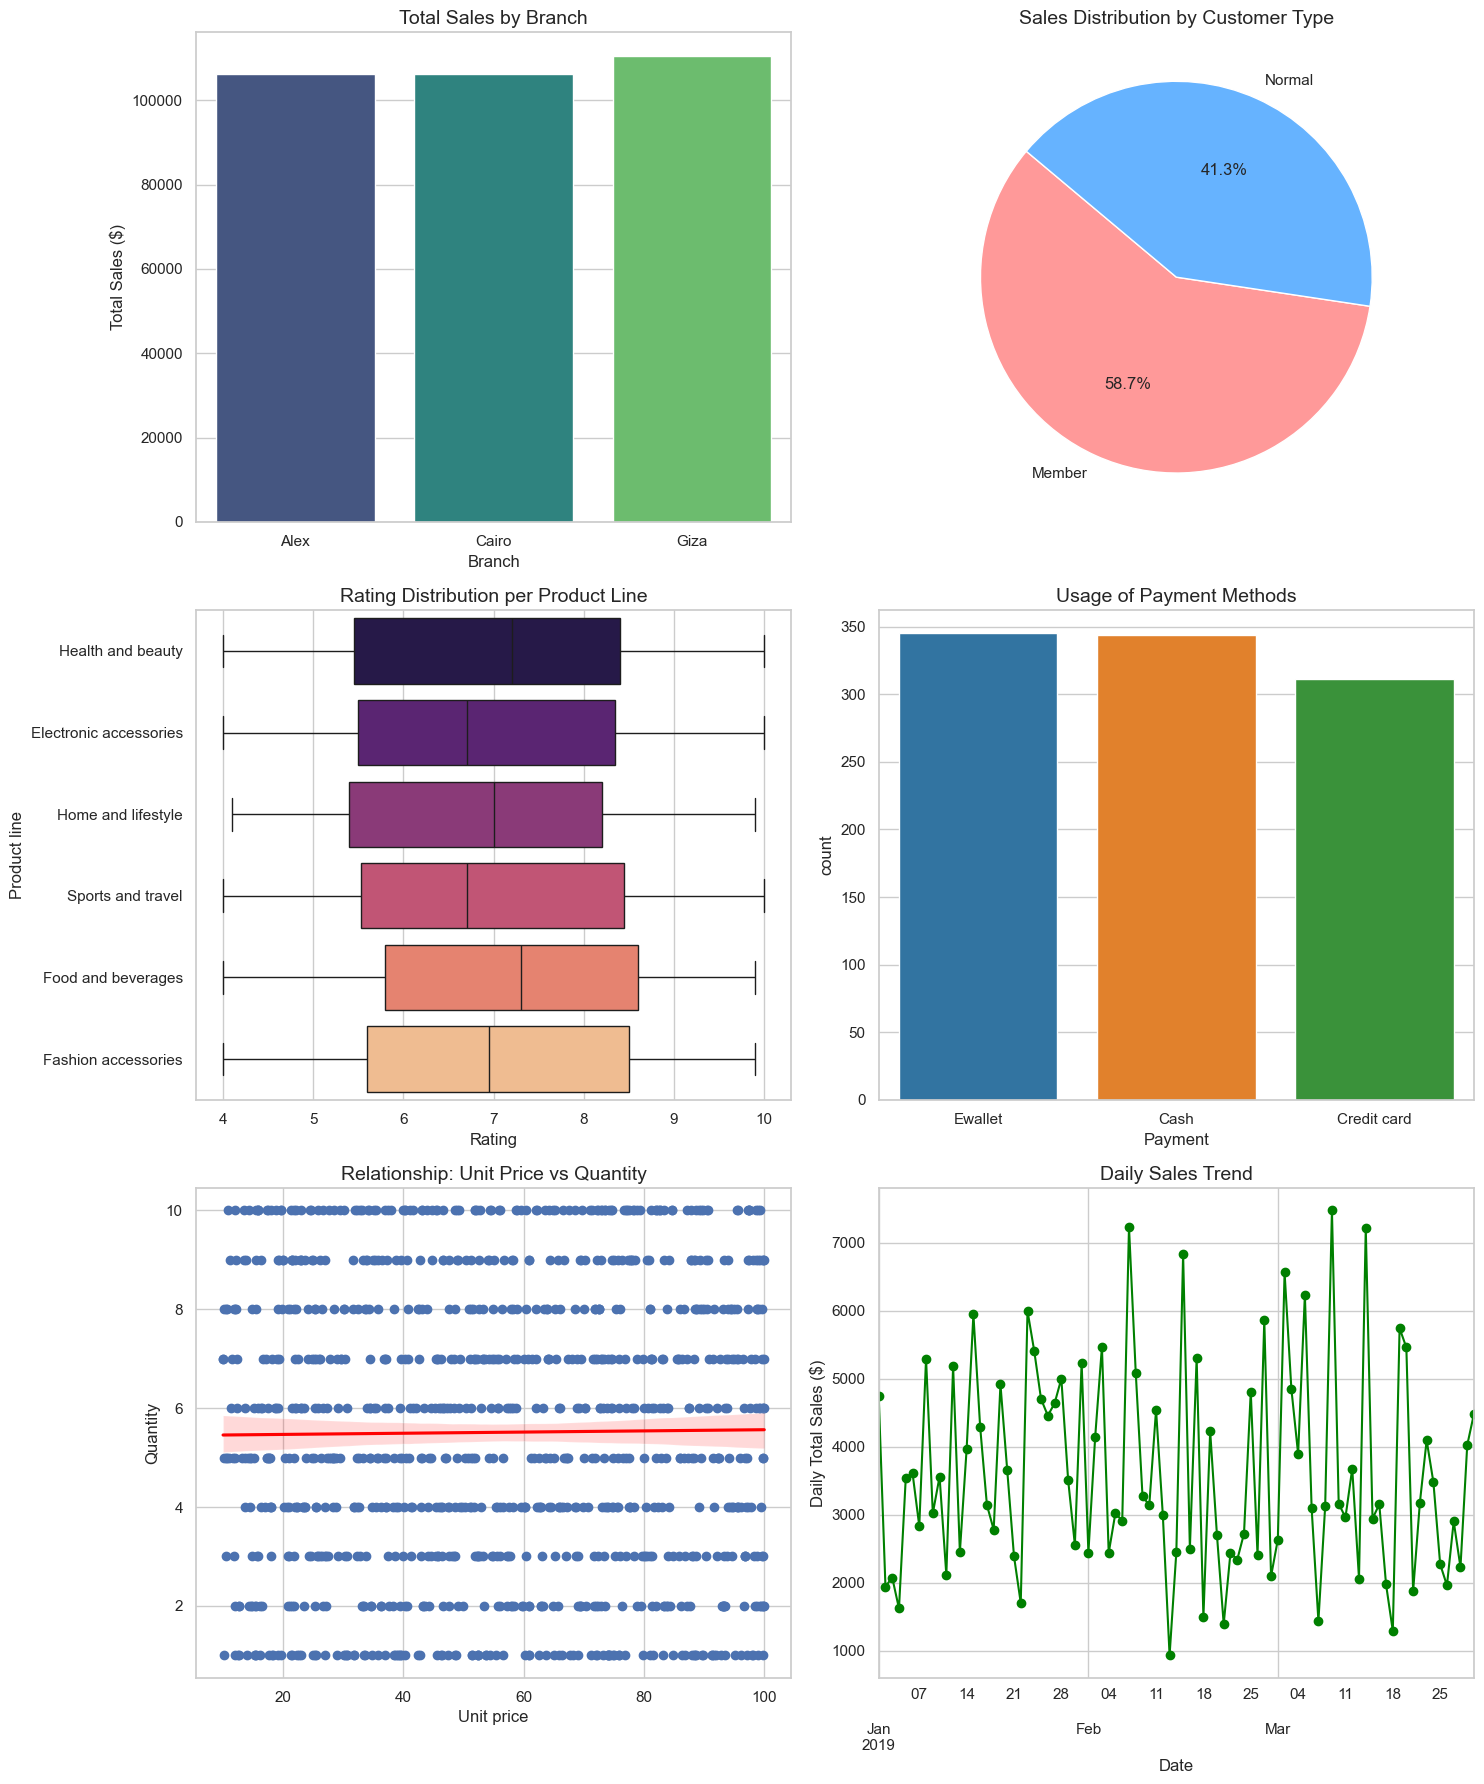

In [12]:
# --- Part 5: Visualization ---

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 18))

# 1. Total Sales by Branch (Bar Chart)
# Fixed: Added hue and legend=False to remove warnings
plt.subplot(3, 2, 1)
sns.barplot(x=branch_sales.index, y=branch_sales.values, hue=branch_sales.index, palette="viridis", legend=False)
plt.title('Total Sales by Branch', fontsize=14)
plt.xlabel('Branch')
plt.ylabel('Total Sales ($)')

# 2. Sales by Customer Type (Pie Chart)
plt.subplot(3, 2, 2)
df.groupby('Customer type')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Sales Distribution by Customer Type', fontsize=14)
plt.ylabel('') # Removes the vertical 'Sales' label

# 3. Rating Distribution by Product Line (Box Plot)
# Fixed: Added hue and legend=False to remove warnings
plt.subplot(3, 2, 3)
sns.boxplot(x='Rating', y='Product line', data=df, hue='Product line', palette="magma", legend=False)
plt.title('Rating Distribution per Product Line', fontsize=14)

# 4. Payment Method Usage (Count Plot)
# Fixed: Added hue and legend=False to remove warnings
plt.subplot(3, 2, 4)
sns.countplot(x='Payment', data=df, hue='Payment', palette="tab10", legend=False)
plt.title('Usage of Payment Methods', fontsize=14)

# 5. Relationship: Unit Price vs Quantity (Scatter Plot with Regression)
plt.subplot(3, 2, 5)
sns.regplot(x='Unit price', y='Quantity', data=df, scatter_kws={'alpha':1}, line_kws={'color':'red'})
plt.title('Relationship: Unit Price vs Quantity', fontsize=14)

# 6. Daily Sales Trend (Line Chart)
plt.subplot(3, 2, 6)
df.groupby('Date')['Sales'].sum().plot(color='green', marker='o')
plt.title('Daily Sales Trend', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Total Sales ($)')

# Final adjustments for layout
plt.tight_layout()
plt.show()